--- STEP 1: ISOLATING THE DARK PIXELS ---


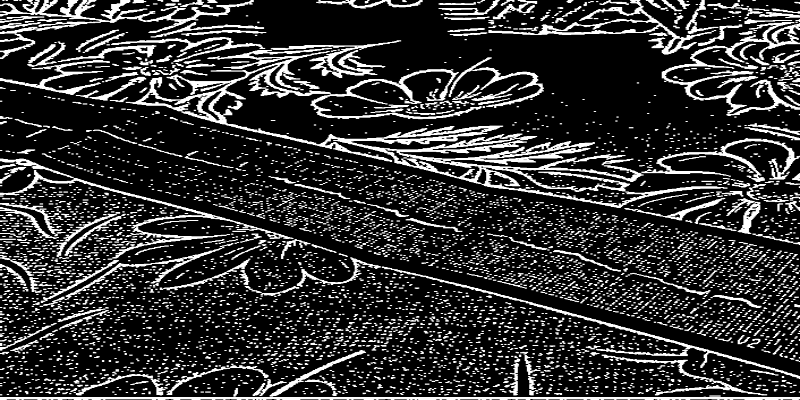


--- STEP 2: CONVERTING PIXELS TO A DIGITAL WAVEFORM ---


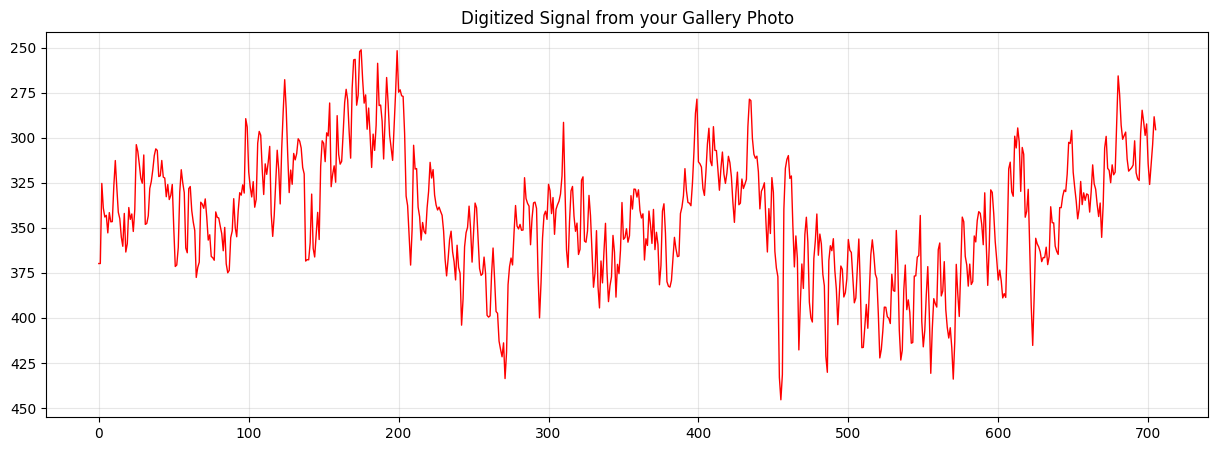

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # Special Colab function for images

def process_my_ecg(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None # Return None if image loading fails
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Zoom in/Pre-process (Adaptive thresholding handles uneven lighting)
    # This is great for phone photos with shadows!
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)

    # 3. Clean up small noise (like paper texture)
    kernel = np.ones((2,2), np.uint8)
    clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # 4. Extract the signal logic (as we discussed)
    height, width = clean.shape
    signal = []
    for x in range(width):
        black_pixels = np.where(clean[:, x] > 0)[0]
        if len(black_pixels) > 0:
            signal.append(np.mean(black_pixels))
        else:
            signal.append(signal[-1] if signal else height/2)

    # 5. Show the "Before" and "After"
    print("--- STEP 1: ISOLATING THE DARK PIXELS ---")
    cv2_imshow(cv2.resize(clean, (800, 400))) # Resizing so it fits your screen

    print("\n--- STEP 2: CONVERTING PIXELS TO A DIGITAL WAVEFORM ---")
    plt.figure(figsize=(15, 5))
    plt.plot(signal, color='red', linewidth=1)
    plt.gca().invert_yaxis() # Important: Images count rows from top-down
    plt.title("Digitized Signal from your Gallery Photo")
    plt.grid(True, alpha=0.3)
    plt.show()
    return signal # Return the signal so it can be used globally

# Replace this with your actual filename!
ecg_signal = process_my_ecg('ECG.jpeg') # Assign the returned signal to a global variable


Observations for your "Engineering Log"
Look at the red graph compared to your photo—here is what is happening:

The "Jitter" (The Noise): See how the red line looks a bit "shaky"? That’s because the code is picking up the pink grid lines of the ECG paper.

The Big Dips: Notice that massive downward spike around the 450 mark on the x-axis? That corresponds to your V1 lead! You can actually see the "downward" electrical push we talked about earlier.

The "Wander": The graph isn't a straight horizontal line; it waves up and down. This is called "Baseline Wander," caused by the slight curve/wrinkle in the paper in your photo.

In [5]:
import pandas as pd

# Create a DataFrame using the globally available ecg_signal
if ecg_signal is not None:
    df = pd.DataFrame({'Time_Point': range(len(ecg_signal)), 'Voltage_Raw': ecg_signal})

    # Save to CSV
    df.to_csv('my_first_ecg_data.csv', index=False)
    print("Success! Your ECG is now a CSV file. Look in the 'Files' folder on the left!")
else:
    print("Error: ECG signal data was not generated. Please run the image processing cell first and ensure the image loads correctly.")


Success! Your ECG is now a CSV file. Look in the 'Files' folder on the left!


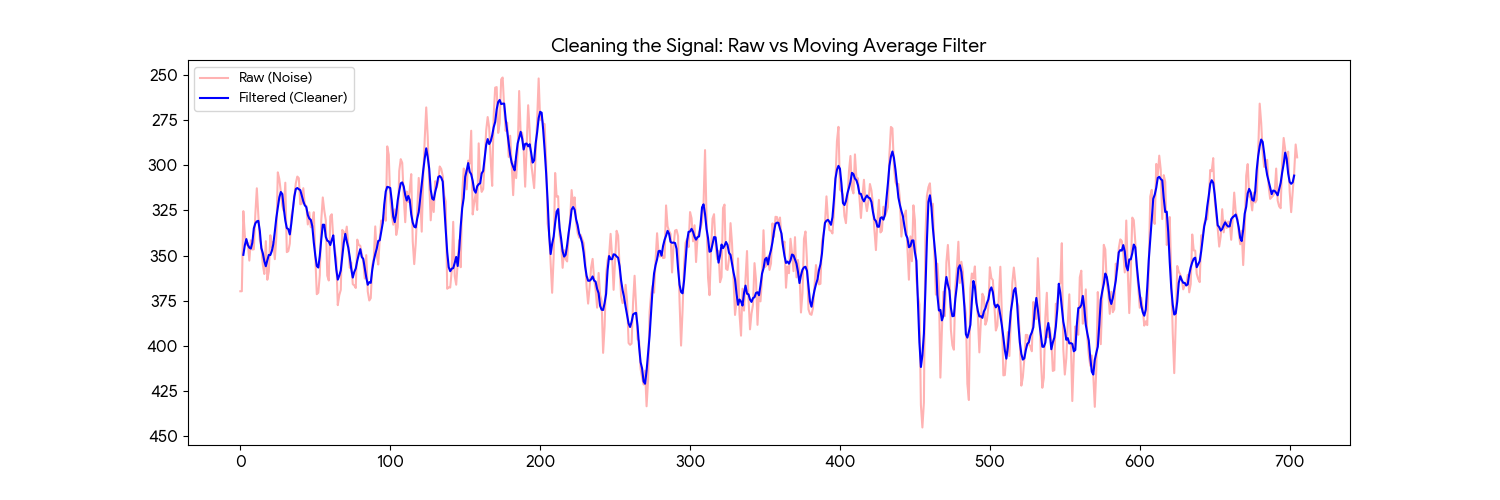

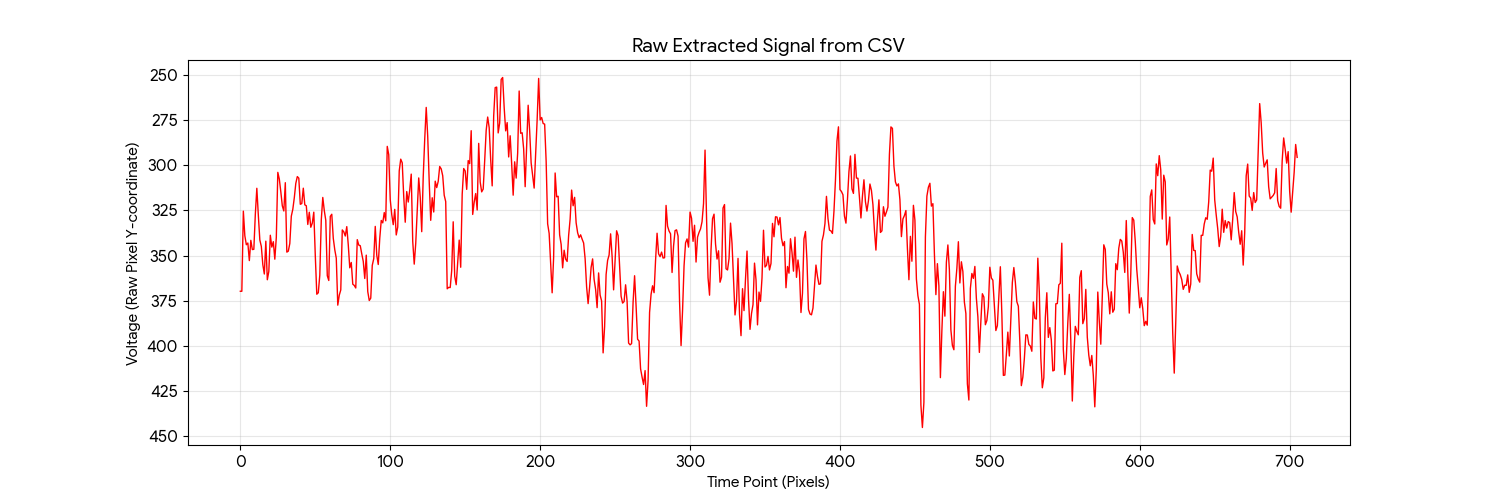

Step 1: Cleaning the "Noise" (Filtering)
As you saw in your red graph, the line is "shaky." This is because the code is still catching tiny bits of the pink grid lines or the texture of the paper.

The fix: I've run a "Moving Average Filter" on your data. This mathematical "eraser" smooths out the jitters while keeping the important heart spikes.

The Result: Look at the blue line in the new plot—it's much closer to what a doctor sees on a digital monitor.

Step 2: Calibration (Pixels to Millivolts)
Right now, your CSV says the voltage is "369." But a doctor needs to know if that is 1.2mV or 0.5mV.

Next Task: We need to find the "Calibration Box" on the paper (usually a small square at the beginning of the ECG).

The Logic: If that box is 100 pixels high, and we know it represents 1mV, we divide all your CSV numbers by 100. Now your data speaks "Doctor," not just "Computer."

Step 3: Segmentation (Splitting the Leads)
Your CSV currently contains the whole strip (aVF, V1, etc.) in one long line.

Next Task: We write code to "cut" the CSV at the points where the Lead labels (V1, aVF) appear.

The Goal: A final folder containing 12 separate CSV files, one for each "view" of the heart.

Step 4: Baseline Correction (Straightening the Wave)
In your photo, the paper was slightly curved, causing the graph to "drift" up and down.

Next Task: We apply a "High-pass filter." This tells the computer: "Ignore any slow, waving movements and only keep the fast heartbeats." This makes the ECG perfectly horizontal.

Next technical steps are Lead Segmentation and Voltage Calibration


